In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 36

(112, 35)


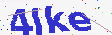

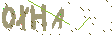

In [6]:
from captchagen import get_captcha_image, generate_captcha, preprocess_image

# 示例使用
image, cookie = get_captcha_image()

# image info
print(image.size)
# show image
from IPython.display import display

display(image)

image, captcha = generate_captcha()
display(image)

In [4]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-stage1',local_files_only=True)
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-stage1',local_files_only=True)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.49.0"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> i

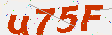

475F


In [11]:
image, cookie = get_captcha_image()
display(image)
pixel_values = processor(image, return_tensors="pt").pixel_values
outputs = model.generate(
    pixel_values,
    max_length=20,  # Set a reasonable maximum length
    num_beams=4,    # Use beam search for better quality
    early_stopping=True  # Stop when all beam hypotheses reach EOS
)
generate_text = processor.batch_decode(outputs, skip_special_tokens=True)[0]
print(generate_text)


In [ ]:
from torch.utils.data import DataLoader
from dataset import CaptchaDataset

def update_dataset():
    dataset = CaptchaDataset("train", 100000, repeat=8,force=True)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)

    test_dataset = CaptchaDataset("test", 256,force=True)
    test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True, drop_last=True)
    return dataloader, test_dataloader

In [ ]:
dataloader, test_dataloader = update_dataset()